# 5.18 Nucleation: The Critical Droplet and the Metastable Lifetime

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume V — Classical Statistical Mechanics",
    number="5.18",
    title="Nucleation: The Critical Droplet and the Metastable Lifetime",
    blurb="Superheated water sits above its boiling point and does nothing, "
    "until it erupts. The Ising model of §5.10 does the same thing once we "
    "give it a magnetic field, and it does it for a reason we can compute: a "
    "small droplet of the stable phase costs more surface than it gains in "
    "bulk, so the new phase has to be born too large to die. We measure the "
    "critical droplet two ways, watch the lifetime grow exponentially as the "
    "driving weakens, and are honest about the one thing this notebook will "
    "not compute.",
    difficulty="advanced",
    estimate="150–190 min",
)

<ECP header: 2856 chars of HTML>

## Notebook overview

A phase can be wrong and still be stable. Water held at $-5\,^\circ$C in a clean, still glass
stays liquid; water heated past $100\,^\circ$C in a smooth mug in a microwave stays liquid, and
then, when something finally disturbs it, boils all at once and all over the counter. In between
the two states there is no continuous downhill path: the system has to build a *piece* of the new
phase before the new phase can lower the free energy at all, and building that piece costs
surface. That cost is a barrier, the barrier makes the wrong phase long-lived, and the whole
subject of **nucleation** is the arithmetic of that one competition.

[§5.15](van-der-waals.ipynb) promised this notebook almost word for word: the metastable strips
between binodal and spinodal decay by rare fluctuations, with a free-energy barrier and Arrhenius
kinetics. We deliver it in the model where every ingredient can be computed exactly rather than
modelled: the two-dimensional Ising magnet of
[§5.10](ising-emergence-universality.ipynb), with one thing added. That notebook had no external
field, and without a field the two ordered states are exactly degenerate, so neither is
metastable. Adding $-H\sum_i\sigma_i$ to the energy tilts them apart, and then a magnet
prepared in the *wrong* well behaves exactly like superheated water: it waits, it looks perfectly
ordinary while it waits, and then it goes.

What we build: the field into the Metropolis update (three lines, and one of them is the physics);
the metastable lifetime and its distribution; cluster identification with `scipy.ndimage.label`,
which this course has never needed before; the critical droplet, measured twice, once by seeding
droplets and asking which ones survive and once from the free energy read off cluster statistics;
and the field dependence of the lifetime, which classical nucleation theory says is
$\ln\tau\propto1/|H|$ in two dimensions. Every prediction is checked against Onsager's exact
interfacial tension and spontaneous magnetization, so the comparison is with real numbers and not
with a fitted curve.

> **How to read the checks.** Each exercise closes with a `validate` call against an independent
> fact: that the field enters the energy difference exactly as the Hamiltonian says and reduces to
> [§5.10](ising-emergence-universality.ipynb) when it is switched off; that the lifetime is
> exponentially distributed, as a single rare event must be; that the labelled clusters of a
> hand-built lattice are the ones we drew; that the critical droplet size scales as $1/|H|$; that
> the free-energy cost of a one-spin cluster is exactly $8J$; that the lifetime obeys $\ln\tau
> \propto1/|H|$ with the Onsager coefficient. Monte Carlo lifetimes are random variables, so every
> check here is a check on a *distribution* or on many seeded runs, never on one realisation.
> A ✓ is strong evidence; a ✗ is a prompt to *locate the discrepancy*.
>
> **Scope, and an honest boundary.** Three limits are drawn deliberately, and each one is drawn in
> the open. **(1) The rate prefactor is out of scope.** We compute the *barrier* — the critical
> droplet, its free energy, and the exponential it puts into the lifetime — and we do not compute
> the attempt frequency in front of that exponential. Getting it right means writing a
> Fokker–Planck equation for the probability flux in cluster-size space, which is the
> Becker–Döring theory and its Zeldovich factor; Landau and Lifshitz carry it out in *Physical
> Kinetics* §99 {cite}`ll_kinetics`, importing the barrier wholesale from equilibrium statistical mechanics exactly as
> we do here. Both of the teaching treatments this notebook follows, Exercise 11.4 of {cite}`sethna` and
> Chapter 5 of {cite}`gould_tobochnik`, stop in the same place. **(2) No umbrella sampling and no
> forward-flux sampling.** We run at driving strong enough that nucleation happens unaided within
> a plain Metropolis run. That is a scope choice, not an oversight:
> [§5.11](taste-of-nonequilibrium.ipynb) assigns rare-event and free-energy methods outward to
> molecular-simulation courses, and Exercise 5 shows precisely where the unaided histogram runs
> out of samples and what an enhanced-sampling method would be for. **(3) Nucleation is not
> coarsening.** Quenching in *temperature* through $T_c$, which
> [§5.10](ising-emergence-universality.ipynb) already animates, gives domain coarsening out of an
> unstable symmetric state; flipping the *field* at fixed temperature gives nucleation out of a
> metastable one. Exercise 8 puts them side by side and measures the difference rather than
> asserting it. Cross-reference [§5.10](ising-emergence-universality.ipynb) (the model and the
> sampler), [§5.8](partition-function.ipynb) (Metropolis),
> [§5.7](potentials-legendre-maxwell.ipynb) (free energy and convexity),
> [§5.15](van-der-waals.ipynb) (the metastable strip this delivers),
> [§5.17](molecular-dynamics.ipynb) (error bars on correlated runs), and
> [E.3](../epilogue/universality.ipynb) (the honest-boundary discipline).

## Theory in brief

### The Ising model acquires a field

[§5.10](ising-emergence-universality.ipynb) worked with spins $\sigma_i=\pm1$ on a square lattice
that pay an energy penalty for disagreeing with their neighbours, and with nothing else. A real
magnet also sits in an applied field, which couples to each spin separately and prefers one
direction outright, so the energy gains a second term,

```{math}
:label: eq-nuc-hamiltonian
E=-J\sum_{\langle ij\rangle}\sigma_i\sigma_j-H\sum_i\sigma_i
\qquad(J>0,\ \text{nearest neighbours, periodic}) .
```

We keep $J=k=1$ throughout, so temperature and field are measured in units of $J$ and the
critical temperature is still Onsager's $T_c=2/\ln(1+\sqrt2)\approx2.269$. The field term destroys
the $\mathbb{Z}_2$ symmetry that was the whole subject of
[§5.10](ising-emergence-universality.ipynb): "all up" and "all down" are no longer degenerate, and
at $H>0$ the up state is the true equilibrium while the down state is merely a local minimum of
the free energy. That asymmetry is the entire point. The lattice, parked in the local minimum, is
**metastable**, and the question of how long it stays there is the question of this notebook.

Metropolis needs only the energy change on flipping one spin. Flipping $\sigma_i$ reverses both
its bond energy and its field energy, so from {eq}`eq-nuc-hamiltonian`

```{math}
:label: eq-nuc-dE
\Delta E_i=2\sigma_i\Bigl(\sum_{j\in\langle i\rangle}\sigma_j+H\Bigr) ,
```

which is [§5.10](ising-emergence-universality.ipynb) with $H$ added *inside* the bracket, beside
the neighbour sum. That placement is the physics: the field acts on the flipping spin like one
more neighbour, of adjustable and non-integer strength. Everything else about the sampler is
unchanged, which is why the update below can be checked against the old one by switching $H$ off.

### Why a metastable phase has to wait

Suppose the field points down, $H<0$, but the lattice is still up. Converting the whole lattice
would lower the free energy, and yet nothing happens for a long time, because the conversion
cannot proceed a spin at a time. Turn over a single spin and it is surrounded by four disagreeing
neighbours: the bond cost $8J$ swamps the field gain $2|H|$, and it flips straight back. Only a
*compact region* of down spins has a favourable surface-to-area ratio, and only if it is large
enough.

That is classical nucleation theory in one sentence, and its arithmetic is a competition between a
perimeter and an area. Write $\sigma$ for the interfacial free energy per unit length of the wall
between the two phases, and $\Delta f$ for the free-energy difference per site between the
metastable phase and the stable one. A circular droplet of the stable phase of radius $R$
embedded in the metastable phase then costs

```{math}
:label: eq-nuc-droplet
\Delta F(R)=2\pi R\,\sigma-\pi R^{2}\,\Delta f ,
\qquad
\Delta f = 2|H|\,m_s(T) ,
```

where the second relation is just bookkeeping: flipping one site from the metastable orientation
to the stable one changes its field energy by $2|H|$, and the phase is magnetized to $m_s$ rather
than fully, so per site the gain is $2|H|m_s$. **State the convention, because the literature
uses several**: our $\Delta f$ is the free-energy difference *per site*, with the factor of two
from $\sigma\to-\sigma$ already inside it. Writers who define $\Delta f=|H|m_s$ report a critical
radius twice ours, and writers who work with a droplet *diameter* rather than a radius report
another factor of two on top. The physics is in the ratio $\sigma/\Delta f$, which is the only
length the problem contains.

The first term of {eq}`eq-nuc-droplet` grows linearly and the second quadratically, so $\Delta F$
rises, turns over, and falls. Setting $\mathrm{d}\Delta F/\mathrm{d}R=0$ gives the **critical
droplet**, and evaluating $\Delta F$ there gives the **barrier**,

```{math}
:label: eq-nuc-critical
R_c=\frac{\sigma}{\Delta f},
\qquad
\Delta F_c=\frac{\pi\sigma^{2}}{\Delta f}
\qquad\text{(circular droplet)} .
```

A droplet smaller than $R_c$ shrinks, because shedding perimeter saves more than shedding area
costs; a droplet larger than $R_c$ grows without limit. The critical droplet is a *saddle*, not a
minimum: it is unstable in the one direction that matters, which is exactly why the reader can
find it by asking which seeded droplets survive.

On a square lattice a square droplet is at least as natural as a round one, and it is what a
seeded configuration will actually look like. Repeating the algebra with a square of side $\ell$,
perimeter $4\ell$ and area $\ell^2$,

```{math}
:label: eq-nuc-square
\ell_c=\frac{2\sigma}{\Delta f},
\qquad
\Delta F_c=\frac{4\sigma^{2}}{\Delta f}
\qquad\text{(square droplet)} ,
```

so the critical square has *half-side* $\sigma/\Delta f$, exactly the critical circle's radius, and
a barrier larger by $4/\pi$. The two conventions bracket the truth. The genuine equilibrium shape
is neither, because the interfacial tension of the Ising model depends on the angle the wall makes
with the lattice; the shape that minimises $\oint\sigma(\theta)\,\mathrm{d}s$ at fixed area is the
**Wulff shape**, a rounded square. We will keep both bracketing forms and report where the
measurement falls between them, which is more honest than choosing one and pretending.

### The two numbers we need, exactly

What makes the Ising model the right laboratory is that both quantities in {eq}`eq-nuc-droplet`
are known in closed form on the square lattice, from the same exact solution that gave
[§5.10](ising-emergence-universality.ipynb) its $T_c$. The spontaneous magnetization is Onsager's
and Yang's, and the interfacial free energy per unit length along a lattice axis is Onsager's,

```{math}
:label: eq-nuc-onsager
m_s(T)=\Bigl[1-\sinh^{-4}\!\bigl(2J/kT\bigr)\Bigr]^{1/8},
\qquad
\sigma(T)=2J+kT\,\ln\tanh\!\bigl(J/kT\bigr) .
```

Neither is derived here — they are quoted results, on the same footing as $T_c$ in
[§5.10](ising-emergence-universality.ipynb), and the exact solution behind them is developed in the
Materials Modelling course and in Chapter 8 of {cite}`sethna`. Both are worth a moment's reading, though.
The tension tends to $2J$ as $T\to0$, which is exactly the bond cost of one unit length of
straight domain wall, and it vanishes at $T_c$, where the two phases stop being distinguishable
and a wall between them costs nothing. At our working temperature $T=1.5$ they take the values
$m_s=0.9865$ and $\sigma=1.1901$, so the only length in the problem is
$\sigma/\Delta f=0.6031/|H|$ lattice spacings: at $|H|=0.25$ the critical droplet is about two and
a half spacings across. Small droplets are what a lattice this size can afford, and the
sharp-interface picture of {eq}`eq-nuc-droplet` is being asked to describe an object only a few
interface widths wide. That is a real limitation and we will see it in the numbers.

### From the barrier to the lifetime

The metastable state decays when a fluctuation carries some region over the saddle. Because the
barrier is large compared with $kT$, that is a rare event, and rare events governed by a barrier
obey an Arrhenius law: the rate per site is $I=A\,\mathrm{e}^{-\Delta F_c/kT}$, the whole lattice
offers $N=L^2$ independent places for it to happen, and the lifetime is the reciprocal of the
total rate,

```{math}
:label: eq-nuc-arrhenius
\tau=\frac{1}{L^{2}A}\,\mathrm{e}^{\Delta F_c/kT}
\quad\Longrightarrow\quad
\ln\tau=\frac{\Xi}{|H|}+\text{const},
\qquad
\Xi=\frac{\pi\sigma^{2}}{2\,m_s\,kT}\ \ \text{(circle)},\ \
\frac{2\sigma^{2}}{m_s\,kT}\ \ \text{(square)} ,
```

where the second form follows by putting $\Delta f=2|H|m_s$ into {eq}`eq-nuc-critical` or
{eq}`eq-nuc-square`. The prediction is sharp and unusual: the logarithm of the lifetime is linear
in the *inverse* field, with a slope fixed by Onsager's two numbers and nothing else. At $T=1.5$
it is $\Xi=1.503$ for the circular convention and $1.914$ for the square one. Exercise 7 measures
it.

The prefactor $A$ is a different matter. It is not a constant — it carries its own field
dependence and its own temperature dependence, and computing it means asking how probability
*flows* through the saddle region in cluster-size space rather than merely how improbable the
saddle is. That calculation is Becker–Döring kinetics with Zeldovich's correction for the
recrossing of a flat barrier top, and it is where a nucleation notebook turns into a physical
kinetics course. We stop at the exponential, say so, and point to Landau and Lifshitz, *Physical
Kinetics* §99 for the rest. One consequence is worth carrying: because $A$ depends on $|H|$ too,
the *apparent* slope of $\ln\tau$ against $1/|H|$ over a narrow window is the barrier coefficient
$\Xi$ plus a prefactor contribution, and separating them needs a range of fields we cannot afford.

### Where the single-droplet picture holds

One more piece of theory, and it is the piece the textbooks leave out. Everything above assumed
that decay proceeds by *one* critical droplet, which then grows to fill the system. Whether that
is true depends on the race between the waiting time $\tau$ for a droplet to appear and the time
$L/v$ for a droplet to sweep across the lattice at its growth velocity $v$. If $\tau\gg L/v$ the
first droplet takes over and the decay is a single stochastic event; if $\tau\lesssim L/v$ many
droplets nucleate independently and the decay is a smooth deterministic filling.
Rikvold, Tomita, Miyashita and Sides {cite}`rikvold1994` map this out and find **four** distinct
field regimes for the metastable lifetime, of which the clean textbook story occupies one. The
crossover field out of the single-droplet regime shrinks only as $1/\ln L$, so it cannot be
escaped by making the system a little smaller.

The two regimes leave different fingerprints, and both are cheap to measure. In the
single-droplet regime the decay is a Poisson process, so the lifetime is **exponentially
distributed** and its standard deviation equals its mean; and because every site is an independent
candidate, $\tau\propto L^{-2}$, so $\tau L^{2}$ is a constant. In the multi-droplet regime the
lifetime is an average over many independent nucleation events, so its distribution is **narrow**
and $\tau$ stops depending on $L$. Exercise 6 measures both fingerprints across lattice sizes and
finds where the crossover sits — including at the parameters the textbooks use.

## Setup

Units are those of [§5.10](ising-emergence-universality.ipynb): $J=k=1$, temperature and field in
units of $J$, lengths in lattice spacings, time in Metropolis sweeps. The data are the working
state point ($T=1.5$, $|H|=0.25$, $L=24$), the series palette with the two-colour map that renders
a spin lattice, and the three exact results quoted from Onsager's solution — the critical
temperature, the spontaneous magnetization, and the interfacial tension of
{eq}`eq-nuc-onsager`. Those last two are closed forms this notebook is handed rather than
machinery it builds; they are the specimen every measurement is compared against. The instruments
are the checkerboard mask builder and a snapshot-plotting scaffold, plus the *zero-field*
Metropolis sweep of [§5.10](ising-emergence-universality.ipynb), restated here because Exercise 1
certifies its own field-carrying replacement against it.

This notebook's own machinery is not here. The field in the energy and in the acceptance rule is
Exercise 1, the metastable driver and the lifetime are Exercise 2, cluster identification is
Exercise 3, and the droplet-survival estimator is Exercise 4. Every run below is driven by the
routines built in those exercises.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullLocator
from scipy import ndimage

from ecp import animate, draw, validate

# data: the series palette, plus the two-colour map a +-1 lattice is drawn with
# (identical to §5.10, so the snapshots here read against those).
ACCENT, INK, SOFT = draw.ACCENT, draw.INK, draw.SOFT
RED = "#c1121f"
SPIN_CMAP = ListedColormap([INK, ACCENT])  # down = ink, up = amber

# data: the working state point of this notebook, in units J = k = 1.
T_WORK = 1.5  # temperature; Sethna's Exercise 11.4 value, and 0.66 T_c
H_WORK = 0.25  # working field magnitude
L_WORK = 24  # working lattice side (Exercise 6 justifies the choice)

# data: Onsager's exact critical temperature (J = k = 1), quoted from the exact
# solution as in §5.10 and not derived here.
T_C = 2.0 / np.log(1.0 + np.sqrt(2.0))

# 4-connectivity structuring element: two sites belong to the same cluster when
# they are nearest neighbours, matching the bonds in the Hamiltonian.
NEIGHBOURS = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=bool)


# data: Onsager's and Yang's exact spontaneous magnetization, eq-nuc-onsager. A
# quoted closed form, the specimen the measurements are judged against.
def onsager_magnetization(T):
    """Exact spontaneous magnetization of the 2-D square-lattice Ising model.

    The closed form m_s = [1 - sinh^-4(2J/kT)]^(1/8) of eq-nuc-onsager, valid
    below T_c and zero above it. Physically the magnitude of the order
    parameter in either ordered phase, which sets how much free energy per
    site a field of strength H buys when a region converts: Delta f = 2|H|m_s.

    Parameters
    ----------
    T : float or numpy.ndarray
        Temperature in units of J/k.

    Returns
    -------
    float or numpy.ndarray
        The spontaneous magnetization, or 0 at and above T_c.
    """
    T = np.asarray(T, float)
    out = np.zeros_like(T)
    cold = T < T_C
    out[cold] = (1.0 - np.sinh(2.0 / T[cold]) ** -4) ** 0.125
    return out if out.ndim else float(out)


# data: Onsager's exact interfacial free energy per unit length along a lattice
# axis, eq-nuc-onsager. Also a quoted closed form.
def onsager_tension(T):
    """Exact interfacial free energy per unit length of the 2-D Ising model.

    The closed form sigma = 2J + kT ln tanh(J/kT) of eq-nuc-onsager, for a wall
    running along a lattice axis. It equals 2J at T = 0, which is the bond cost
    of one unit length of straight domain wall, and vanishes at T_c, where the
    two phases become indistinguishable. Note that the tension of the square
    lattice is anisotropic; this is its value in the soft direction.

    Parameters
    ----------
    T : float or numpy.ndarray
        Temperature in units of J/k.

    Returns
    -------
    float or numpy.ndarray
        The interfacial free energy per unit length, in units of J.
    """
    return 2.0 + T * np.log(np.tanh(1.0 / T))


# instrument: the checkerboard decomposition. Bookkeeping the sweep needs and
# that §5.10 already explained; no exercise here is about lattice colouring.
def checkerboard_masks(L):
    """The two sublattice masks of an L x L square lattice.

    Sites with (i + j) even have no even neighbours, so a whole colour may be
    updated at once and the sweep stays exact while vectorizing.

    Parameters
    ----------
    L : int
        Linear lattice size.

    Returns
    -------
    tuple of numpy.ndarray
        The two boolean masks, even parity first.
    """
    ii, jj = np.indices((L, L))
    return ((ii + jj) % 2 == 0, (ii + jj) % 2 == 1)


# built from scratch in §5.10; restated here as an instrument. The zero-field
# Metropolis sweep, kept verbatim so Exercise 1 can certify its field-carrying
# replacement against it on a shared random stream.
def ising_sweep(s, beta, rng, masks):
    """One zero-field Metropolis sweep of the 2-D Ising lattice, in place.

    The sweep of §5.10: a checkerboard neighbour sum by ``numpy.roll`` with
    periodic wrap, and the Metropolis acceptance ``rng.random(...) <
    exp(-beta*dE)`` with dE = 2 J sigma_i sum_nbr sigma_j. Restated here only
    as the reference the field version reduces to at H = 0.

    Parameters
    ----------
    s : numpy.ndarray
        The L x L spin lattice (values +-1); modified in place.
    beta : float
        Inverse temperature 1/kT.
    rng : numpy.random.Generator
        Random generator (``numpy.random.default_rng``).
    masks : tuple of numpy.ndarray
        The two checkerboard boolean masks.

    Returns
    -------
    None
        Updates ``s`` in place.
    """
    for mask in masks:
        nbr = (
            np.roll(s, 1, 0) + np.roll(s, -1, 0) + np.roll(s, 1, 1) + np.roll(s, -1, 1)
        )
        dE = 2.0 * s * nbr
        flip = (rng.random(s.shape) < np.exp(-beta * dE)) & mask
        s[flip] *= -1


# instrument: a snapshot-plotting scaffold. Six figures below draw a lattice the
# same way; how it is drawn is not the lesson of any of them.
def show_lattice(ax, s, title=""):
    """Draw a +-1 spin lattice as a two-colour image on the given axes.

    Down spins render in ink and up spins in amber, with the colour scale
    pinned so the eye sees the configuration and never an autoscaling artefact.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Target axes.
    s : numpy.ndarray
        The L x L spin lattice.
    title : str, optional
        Axes title (default empty).

    Returns
    -------
    matplotlib.image.AxesImage
        The image artist, so an animation can update its data in place.
    """
    im = ax.imshow(s, cmap=SPIN_CMAP, interpolation="nearest", vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)
    return im


M_S = float(onsager_magnetization(T_WORK))
SIGMA = float(onsager_tension(T_WORK))

## Exercise 1 — The field in the energy, and in the acceptance rule (student)

Everything this notebook does rests on one modification of the sampler of
[§5.10](ising-emergence-universality.ipynb), so it is worth getting exactly right and worth
certifying properly. The energy is {eq}`eq-nuc-hamiltonian`, $E=-J\sum_{\langle
ij\rangle}\sigma_i\sigma_j-H\sum_i\sigma_i$ with $J=1$ and periodic boundaries, and the energy
change on flipping the single spin $\sigma_i$ is {eq}`eq-nuc-dE`, $\Delta
E_i=2\sigma_i(\sum_{j\in\langle i\rangle}\sigma_j+H)$: the field sits *inside* the bracket, added
to the neighbour sum, because it acts on the flipping spin exactly as one more neighbour would
({numref}`fig-nucleation-flip`). Writing it outside — $2\sigma_i\sum_j\sigma_j+H$ — is the
natural slip, and it is invisible at $H=0$, so the check below is built to catch it at $H\ne0$
rather than to reassure at $H=0$.

The certification has three parts because there are three things that can be wrong, and each part
is chosen so that it can actually fail. **First**, the bracket. Rather than trusting
{eq}`eq-nuc-dE`, compute $\Delta E_i$ the slow honest way for *every* site of a generic random
$8\times8$ lattice at the deliberately non-round field $H=0.37$: evaluate the total energy, flip
site $i$, evaluate it again, take the difference, and compare with the formula. A misplaced field
term disagrees at every site. **Second**, the reduction. At $H=0$ the new sweep must be the old
sweep, not merely similar to it: driven from the same seed on the same starting lattice, the two
consume their random numbers in the same order and must produce *bitwise identical*
configurations. Run that comparison on a random $16\times16$ lattice at $T=2.5$, hot enough that
a large fraction of sites flips every sweep, so agreement is a real coincidence and not the
trivial agreement of two lattices that never move. **Third**, the converse: at $H=0.4$ on the
same stream the two must *differ*, which is what shows the field term is alive rather than
multiplied by zero somewhere.

**Part a)** Write `ising_energy(s, h)` returning the total energy of {eq}`eq-nuc-hamiltonian` for
a lattice `s` at field `h`, counting each bond once (sum $s\cdot$`numpy.roll(s,-1,axis)` over the
two axes, which visits every periodic bond exactly once) and subtracting `h * s.sum()`.

**Part b)** Write `ising_sweep_field(s, beta, h, rng, masks)`, one in-place Metropolis sweep at
field `h`: form the neighbour sum with the four `numpy.roll` shifts as in
[§5.10](ising-emergence-universality.ipynb), build `dE` from {eq}`eq-nuc-dE`, and accept with
`rng.random(s.shape) < np.exp(-beta*dE)` restricted to each checkerboard mask in turn.
**Write this one yourself** — the implementation is the lesson: the field's place inside the
bracket is the only new physics in the notebook, and it is the one line a library call would
hide.

**Part c)** Certify the two of them by the three tests above, and report the largest
formula-versus-brute-force discrepancy over the 64 sites, whether the $H=0$ lattices are
identical, and the fraction of sites at which the $H=0.4$ lattices differ.

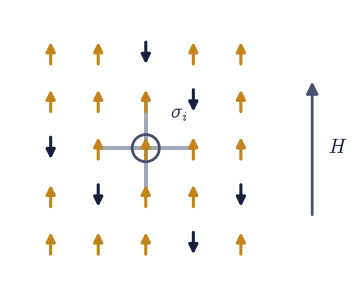

In [3]:
# (solution hidden on the public site)


In [4]:
# (solution hidden on the public site)


the field in the energy difference, eq-nuc-dE  (T = 2.5, 30 sweeps):
  formula vs brute force over all 64 sites at h = 0.37: max gap = 8.88e-16
  h = 0 reduces to the §5.10 sweep, bitwise: True   (that run moved 52% of the sites, so the match is not trivial)
  h = 0.4 on the same stream differs at 86% of sites — the field is live


### Validation 1

In [5]:
validate.check(
    dE_gap < 1e-10 and identical and moved > 0.2 and differ > 0.05,
    "the field enters the flip energy inside the bracket, dE = 2 sigma (sum_nbr + H): "
    "the formula matches a brute-force energy difference at every site, the sweep "
    "reduces bitwise to the zero-field sweep of §5.10 on a configuration that moves, "
    "and it genuinely differs once the field is switched on",
    f"max |dE gap| = {dE_gap:.1e}, sites moved = {moved:.2f}, sites differing at h=0.4 = {differ:.2f}",
)

✓  the field enters the flip energy inside the bracket, dE = 2 sigma (sum_nbr + H): the formula matches a brute-force energy difference at every site, the sweep reduces bitwise to the zero-field sweep of §5.10 on a configuration that moves, and it genuinely differs once the field is switched on   [max |dE gap| = 8.9e-16, sites moved = 0.52, sites differing at h=0.4 = 0.86]


True

## Exercise 2 — A magnet in the wrong well, and how long it stays there (student)

Now the experiment the whole notebook is about. Prepare a lattice deep in the ordered phase at
$T=1.5$ with the field pointing *up*, $H=+0.25$, so the magnetization settles near
$+m_s=+0.9865$ and the configuration is a placid sea of up spins. Then reverse the field to
$H=-0.25$ without touching the temperature. Nothing about the lattice changes at that instant, but
everything about its status does: the state it is in has become the *wrong* one, higher in free
energy than the down state by $\Delta f=2|H|m_s$ per site, and the only thing keeping it there is
the droplet barrier of {eq}`eq-nuc-critical`.

What follows is the signature of metastability, and it looks nothing like a relaxation. The
magnetization does not drift downward. It sits at $+m_s$, indistinguishable from equilibrium, for
a while that varies wildly from run to run, and then it collapses to $-m_s$ over a few tens of
sweeps ({numref}`fig-nucleation-decay`). Define the **lifetime** $\tau$ as the first sweep at
which $m$ crosses zero, the standard choice in both {cite}`gould_tobochnik` and Exercise 11.4
of {cite}`sethna`, and the collapse is fast enough that the answer barely depends on where the
threshold is put.

The distribution of $\tau$ over many seeds is the first real physics here, and it is a stronger
statement than the mean. If the decay is triggered by a single rare event that is equally likely
in every sweep and carries no memory of how long the system has already waited, then $\tau$ is
**exponentially distributed**: the survival probability is

```{math}
:label: eq-nuc-survival
P(\tau>t)=\mathrm{e}^{-t/\tau_{\text{mean}}} ,
```

whose standard deviation equals its mean and whose logarithm is a straight line against $t$. That
is a genuine test of the nucleation picture, not a restatement of it: a decay proceeding by steady
growth from the moment of the flip, or by many simultaneous events, would give a narrow
distribution instead. So the check is on the shape of the histogram over 150 seeded runs, never on
any one of them.

**Part a)** Write `metastable_run(L, T, h, rng, n_sweeps, burn=60)`, which allocates an all-up
$L\times L$ lattice, equilibrates it for `burn` sweeps at field $+h$ with the
`ising_sweep_field` of Exercise 1, then runs `n_sweeps` sweeps at field $-h$ and returns the
per-sweep magnetization $m=\frac1N\sum_i\sigma_i$ together with the final configuration.

**Part b)** Write `lifetime(L, T, h, seed, max_sweeps)`, which performs the same preparation from
`numpy.random.default_rng(seed)` and returns the first sweep index after the reversal at which
$m<0$, or `max_sweeps` if the run survives that long.

**Part c)** Plot six magnetization traces at $L=32$, $|H|=0.25$, $T=1.5$ over 1200 sweeps, with
the two equilibrium levels $\pm m_s$ marked, and confirm by eye that the waiting time and not the
collapse is what varies.

**Part d)** Collect 150 lifetimes at $L=24$, $|H|=0.25$, $T=1.5$ from seeds $500\ldots649$ with
`max_sweeps=20000`; report the mean, the median, and the ratio of standard deviation to mean; and
fit $\ln P(\tau>t)$ against $t$ over the lower 85% of the sorted lifetimes (`numpy.polyfit`,
degree 1) to test {eq}`eq-nuc-survival`. For an exponential the ratio is $1$ and the median is
$\ln2\approx0.693$ times the mean.

In [6]:
# (solution hidden on the public site)


metastable decay at T = 1.5, |H| = 0.25, L = 24  (150 seeded runs):
  mean lifetime             652.1 sweeps
  median lifetime           482.5 sweeps   (an exponential gives 452.0)
  std / mean                0.879          (an exponential gives 1)
  log-survival fit       slope -0.00159 vs -1/tau = -0.00153,  R^2 = 0.9922
  runs censored at 20000 sweeps: 0


### Validation 2

In [7]:
validate.check(
    0.7 < tau_rel < 1.3 and surv_r2 > 0.97 and (tau_samples >= 20000).sum() == 0,
    "the metastable lifetime is exponentially distributed over 150 seeded runs — "
    "the decay is a memoryless rare event, not a steady relaxation",
    f"std/mean = {tau_rel:.2f} (exponential: 1), log-survival R^2 = {surv_r2:.3f}",
)

✓  the metastable lifetime is exponentially distributed over 150 seeded runs — the decay is a memoryless rare event, not a steady relaxation   [std/mean = 0.88 (exponential: 1), log-survival R^2 = 0.992]


True

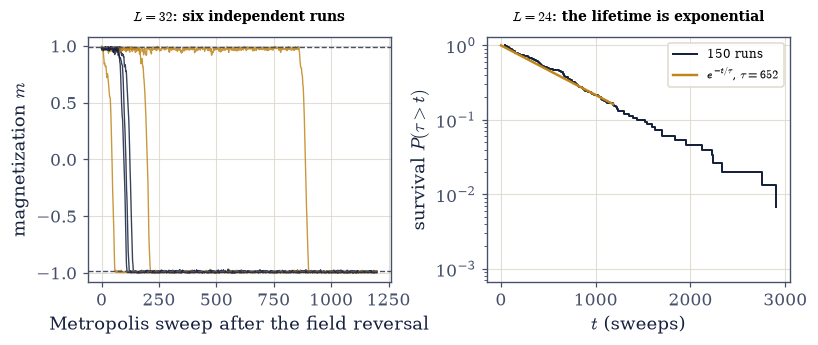

In [8]:
# (solution hidden on the public site)


## Exercise 3 — Finding the droplets (student)

The traces of Exercise 2 say *when* the decay happens and say nothing at all about *what* happens,
and everything that follows needs the configurations rather than their average. A droplet is a
connected region of minority spins, so we need to be able to take a lattice and hand back a list
of its connected regions with their sizes. That is a standard image-processing operation and this
course has not needed it once in seventeen notebooks: `scipy.ndimage.label` walks a boolean array
and assigns every connected component an integer, and `numpy.bincount` on the result counts them.
Connectivity has to be declared, and the declaration is physics rather than convention: two sites
belong to the same droplet when they are nearest neighbours, because those are the pairs the
Hamiltonian {eq}`eq-nuc-hamiltonian` couples, so the structuring element is the four-neighbour
cross `NEIGHBOURS` of the Setup and not the eight-neighbour square that `scipy` uses by default.

One honest limitation comes with the tool. The lattice is periodic but `scipy.ndimage.label` is
not: a droplet straddling the left and right edges is returned as two clusters rather than one.
For everything this notebook measures that is harmless, because the clusters we care about are
the small subcritical ones fluctuating inside the metastable phase, and by the time a droplet is
wide enough to wrap around the lattice it has long since crossed the barrier and stopped being a
droplet. Rather than assume the harm is small, Part c) measures it: the fraction of clusters that
touch any edge of the lattice at all is an upper bound on the fraction that could be mis-split.

**Part a)** Write `label_clusters(s, value)` which labels the connected components of
`s == value` with `scipy.ndimage.label(..., structure=NEIGHBOURS)` and returns the label array
together with a `numpy.bincount`-derived array of cluster sizes with the background dropped.

**Part b)** Certify it on the $6\times6$ configuration below, which is all up except for a
deliberate arrangement of down spins: an isolated site at $(0,0)$, a horizontal pair at
$(2,3),(2,4)$, a four-site L at $(4,1),(5,1),(5,2),(5,3)$, and a diagonal touching pair at
$(0,4),(1,5)$ that four-connectivity must count as *two* clusters and eight-connectivity would
wrongly merge into one. The sorted sizes must come back as $[1,1,1,2,4]$.

**Part c)** Take a snapshot of the metastable phase at $L=64$, $T=1.5$, $H=-0.25$ after 40 sweeps
using the `metastable_run` of Exercise 2, label its down-spin clusters, and report how many there
are, the size of the largest, the mean size, and the fraction touching an edge. The lattice is
still magnetized at $m\approx+0.95$ at that moment, so what the labels find are fluctuations
inside the metastable phase and not the aftermath of a decay.

In [9]:
# (solution hidden on the public site)


cluster labelling with scipy.ndimage.label and four-connectivity:
  hand-built 6x6 lattice: sorted cluster sizes = [1, 1, 1, 2, 4]   (expected [1, 1, 1, 2, 4])
  metastable snapshot, L = 64, 40 sweeps at H = -0.25:
    35 down clusters, largest 18 sites, mean 2.71, lattice still at m = +0.954
    fraction touching a lattice edge: 0.057 — an upper bound on those the non-periodic labelling could split


### Validation 3

In [10]:
validate.check(
    sizes_sorted == [1, 1, 1, 2, 4] and edge_fraction < 0.2,
    "the four-connected labelling returns exactly the clusters drawn on the "
    "hand-built lattice, keeping the corner-touching pair apart, and the "
    "boundary-splitting error of the non-periodic labeller is bounded below 20%",
    f"sizes = {sizes_sorted}, edge fraction = {edge_fraction:.3f}",
)

✓  the four-connected labelling returns exactly the clusters drawn on the hand-built lattice, keeping the corner-touching pair apart, and the boundary-splitting error of the non-periodic labeller is bounded below 20%   [sizes = [1, 1, 1, 2, 4], edge fraction = 0.057]


True

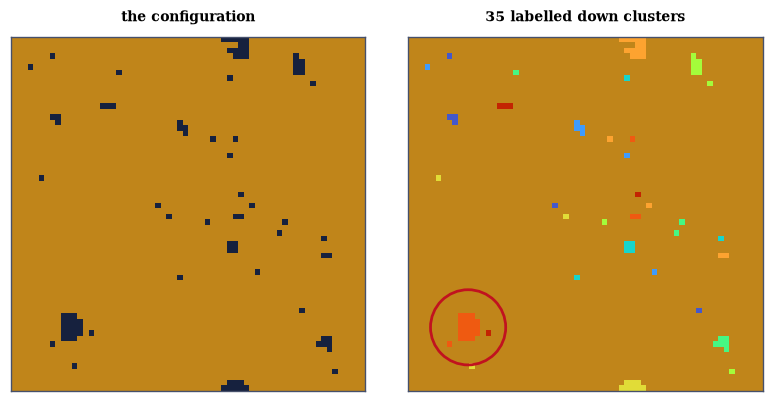

In [11]:
# (solution hidden on the public site)


### The decay, watched

The traces and the cluster counts describe the same event from two sides, and the event itself is
worth seeing. What follows is a single $64\times64$ run at $T=1.5$ after the field is reversed to
$H=-0.25$, snapshotted every second sweep ({numref}`fig-nucleation-anim`). The metastable phase
fluctuates without going anywhere, small dark patches appearing and vanishing; then one of them
does not vanish, and from that moment the outcome is decided. Watch for one thing in particular,
because Exercise 6 will make it quantitative: whether the lattice is taken over by *one* droplet
or by several that appear at about the same time and then run into each other.

In [12]:
# (solution hidden on the public site)


decay animation: 64 frames over 126 sweeps, m from +0.993 to -0.885


In [13]:
# (solution hidden on the public site)


In [14]:
# (solution hidden on the public site)


### Validation 3b

In [15]:
validate.check(
    anim_m[0] > 0.9 * M_S
    and anim_m[-1] < -0.5
    and min(anim_m[: len(anim_m) // 3]) > 0.85,
    "the animated run begins at the metastable equilibrium, holds there through "
    "the first third of its life, and then converts completely — a waiting time "
    "followed by a collapse, not a drift",
    f"m: {anim_m[0]:+.3f} -> {anim_m[-1]:+.3f}",
)

✓  the animated run begins at the metastable equilibrium, holds there through the first third of its life, and then converts completely — a waiting time followed by a collapse, not a drift   [m: +0.993 -> -0.885]


True

## Exercise 4 — The critical droplet, route one: which droplets survive (student)

The critical droplet of {eq}`eq-nuc-critical` is defined by an instability, and an instability can
be measured directly rather than inferred. Plant a droplet of the stable phase by hand, of a size
we choose, in an otherwise metastable lattice; let the dynamics run; and record whether it grew or
died. Small droplets almost always die and large ones almost always grow, so the probability of
growth rises from zero to one as the seeded size increases, and the size at which it passes
$\tfrac12$ is the critical droplet as the dynamics itself defines it. This is the *committor*
construction, and it needs no free-energy calculation at all.

Seed **squares** rather than discs. A disc rasterized onto a lattice has a ragged perimeter whose
length jumps about as the radius changes, so its survival probability is not even monotonic in the
radius; a square of side $\ell$ has perimeter exactly $4\ell$, which is why {eq}`eq-nuc-square`
was worth writing down. The prediction to test is therefore $\ell_c=2\sigma/\Delta f$ with
$\Delta f=2|H|m_s$, which at $T=1.5$ is $\ell_c=1.206/|H|$ lattice spacings: $8.0$ at $|H|=0.15$,
$6.0$ at $|H|=0.20$, and $4.8$ at $|H|=0.25$. Because the notebook's whole scaling claim is that
the only length in the problem is $\sigma/\Delta f$, the sharper test is not any one of those
numbers but whether $\ell_{50}\,|H|$ comes out the same at all three fields.

Two details make the measurement mean what it should. Growth is judged by the cluster
*containing the centre site*, found with the `label_clusters` of Exercise 3, rather than by the
magnetization: a droplet nucleating spontaneously somewhere else in the lattice would move $m$
without saying anything about the seeded one. And the verdict is taken early — the run stops as
soon as the central cluster either vanishes or reaches three times its initial area — so a
supercritical droplet is scored on the way up rather than after it has swallowed the lattice.
A $36\times36$ lattice run for at most 100 sweeps is large enough that a tripled droplet is still
far from the boundary, and short enough that spontaneous nucleation elsewhere is rare.

**Part a)** Write `seed_square(L, ell)` returning an all-up $L\times L$ lattice with a centred
$\ell\times\ell$ block of down spins.

**Part b)** Write `growth_probability(L, T, h, ell, n_runs, n_sweeps)`, which for each of
`n_runs` seeds runs `ising_sweep_field` at field $-h$ on a freshly seeded lattice, tracks the
size of the four-connected down cluster containing the centre site with `label_clusters`, scores
the run $1$ if that cluster reaches $3\ell^2$ and $0$ if it disappears, and returns the fraction
scored $1$. **Write this one yourself** — the implementation is the lesson: what counts as
"this droplet, still" is the whole content of a committor measurement, and the answer changes if
the criterion does.

**Part c)** Measure $P_{\text{grow}}(\ell)$ for $\ell=3,4,\ldots,10$ and $12$ at $|H|=0.15$,
$0.20$ and $0.25$, with $T=1.5$, $L=36$, 120 runs and at most 100 sweeps each; find $\ell_{50}$ at
each field by linear interpolation (`numpy.interp` on the monotonic part of the curve); and
compare $\ell_{50}$ with $\ell_c=2\sigma/\Delta f$ and $\ell_{50}|H|$ across the three fields.

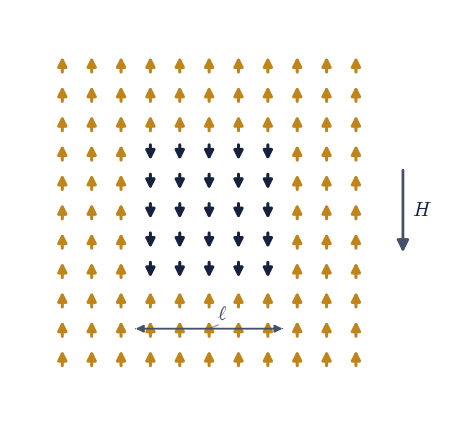

In [16]:
# (solution hidden on the public site)


In [17]:
# (solution hidden on the public site)


critical droplet from seeded-droplet survival (T = 1.5, L = 36, 120 runs each):
  |H| = 0.15:  ell_50 =  9.67   CNT ell_c =  8.04 (square, eq-nuc-square)   ratio 1.20   ell_50*|H| = 1.450
  |H| = 0.20:  ell_50 =  7.59   CNT ell_c =  6.03 (square, eq-nuc-square)   ratio 1.26   ell_50*|H| = 1.517
  |H| = 0.25:  ell_50 =  6.44   CNT ell_c =  4.83 (square, eq-nuc-square)   ratio 1.33   ell_50*|H| = 1.610
  ell_50*|H| varies by 11.0% across the three fields (CNT: exactly constant at sigma/m_s = 1.206)


### Validation 4

In [18]:
validate.check(
    scaled_spread < 0.15
    and all(1.0 < ell_50[h] / ell_cnt[h] < 1.6 for h in fields_c)
    and all(committor[h][0] < 0.15 and committor[h][-1] > 0.7 for h in fields_c),
    "the measured critical droplet scales as 1/|H|, as classical nucleation "
    "theory requires when sigma/Delta f is the only length in the problem, and "
    "sits within 60% of the sharp-interface square-droplet prediction",
    f"ell_50*|H| spread = {100 * scaled_spread:.1f}%, "
    f"ratios to CNT = {[round(ell_50[h] / ell_cnt[h], 2) for h in fields_c]}",
)

✓  the measured critical droplet scales as 1/|H|, as classical nucleation theory requires when sigma/Delta f is the only length in the problem, and sits within 60% of the sharp-interface square-droplet prediction   [ell_50*|H| spread = 11.0%, ratios to CNT = [1.2, 1.26, 1.33]]


True

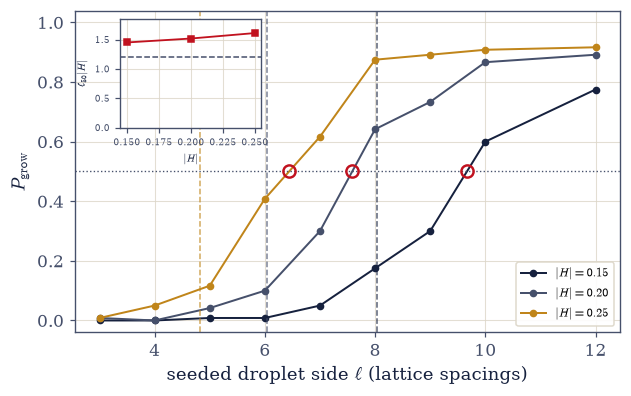

In [19]:
# (solution hidden on the public site)


## Exercise 5 — The critical droplet, route two: a free energy read off a histogram (worked)

The committor found the saddle by watching the dynamics fall off it. The other route is
thermodynamic and needs no dynamics at all, only the equilibrium statistics of the metastable
phase. If $n(s)$ is the number of clusters of size $s$ per lattice site in the metastable basin,
then those clusters are Boltzmann-distributed over their free energy of formation and

```{math}
:label: eq-nuc-clusterfe
F(s)=-kT\ln n(s) ,
```

so a histogram of cluster sizes *is* a free-energy profile along the droplet-size coordinate,
measured rather than modelled. The droplet picture predicts its shape: a perimeter term rising as
$\sqrt s$, because a compact cluster of area $s$ has a boundary of length proportional to
$\sqrt s$, minus the bulk term $\Delta f\,s$ of {eq}`eq-nuc-droplet` that the field supplies.

Two things can be checked against exact answers, and they are worth checking first because they
certify the histogram before anything is fitted to it. At $H=0$ a single overturned spin has four
unsatisfied bonds and no alternative shape, so its formation free energy is exactly $8J$ with no
entropy correction whatever the temperature. A two-site cluster has six unsatisfied bonds and
exactly two orientations, horizontal or vertical, so its free energy is $12J-kT\ln2$. Those are
the first two points of the histogram, known in closed form.

The field term is then isolated in a way that owes nothing to droplet shapes at all. Run the same
measurement twice, once at $H=0$ and once at $H\ne0$; the surface cost of a given cluster is the
same in both, so the whole difference is the bulk term,

$$F_{H=0}(s)-F_{H}(s)=kT\ln\frac{n_H(s)}{n_0(s)}=\Delta f\,s=2|H|m_s\,s ,$$

a straight line through the origin whose slope is Onsager's $2|H|m_s$ and nothing else. That is
the sharpest quantitative statement in the notebook, and it is a genuine prediction: the slope was
computed from the exact solution before any lattice was swept.

**Where this route stops, and why.** The histogram is a free energy only where there are counts,
and a plain Metropolis run in the metastable basin produces clusters of size $10$ perhaps once in
a million site-samples and clusters of the critical size essentially never. That is not a defect
of the measurement; it is the barrier, seen from the sampling side. Climbing it needs a method
that biases the simulation towards the sizes it never visits and then removes the bias —
umbrella sampling, or forward-flux sampling for the dynamical version — and this notebook
deliberately does not use one. [§5.11](taste-of-nonequilibrium.ipynb) hands rare-event and
free-energy methods outward to molecular-simulation courses, and running at driving strong enough
that nucleation happens unaided is how we honour that. So the barrier here is obtained by fitting
the two terms where the statistics exist and *extrapolating* {eq}`eq-nuc-square` to the saddle,
which is exactly what classical nucleation theory does and exactly as trustworthy. The
extrapolation is worth doing precisely because it shows its own weakness: the surface coefficient
fitted to clusters of ten sites is not Onsager's asymptotic $4\sigma$ but something appreciably
larger, because a cluster that small is mostly corners and has not yet acquired the wandering
entropy that softens a long wall. It must lie between $4\sigma$ and the entropy-free $T=0$
perimeter cost $8J$, and it does; but squaring it and dividing by $\Delta f$ magnifies the gap,
so the extrapolated barrier is substantially larger than the asymptotic one. Reaching the saddle
honestly needs the sampling method we are not using, and this is what that costs.

Sampling is pooled over 60 independent preparations of a $64\times64$ lattice, a snapshot every
second sweep for at most 60 snapshots, and a run is abandoned the moment its magnetization drops
below $0.8$, since past that point the lattice is decaying rather than fluctuating.

In [20]:
# (solution hidden on the public site)


cluster free energy F(s) = -kT ln n(s) at T = 1.5, L = 64 (3600 pooled snapshots at H = 0):
  F(1) = 8.032  vs exact 8J          (a single flipped spin, 4 broken bonds)
  F(2) = 11.060  vs exact 12J - kT ln2 = 10.960  (2 orientations)
  the field term, isolated as F_0(s) - F_H(s) over s = 1...10:
    |H| = 0.15:  slope 0.3029   predicted 2|H|m_s = 0.2959   ratio 1.023
    |H| = 0.25:  slope 0.4907   predicted 2|H|m_s = 0.4932   ratio 0.995
  surface term over the same range: F_0(s) ~ 6.16 sqrt(s), bracketed by Onsager's 4*sigma = 4.76 (asymptotic) and 8J (the T = 0 perimeter cost, no entropy yet)
  extrapolating those two fitted terms to the saddle, against CNT with Onsager's sigma:
    |H| = 0.15:  barrier  31.3 vs  19.1  (the fit overshoots by 64%, all of it from the surface coefficient)
    |H| = 0.25:  barrier  19.3 vs  11.5  (the fit overshoots by 68%, all of it from the surface coefficient)
  largest cluster with any counts at H = 0: s = 18   (the critical size is 23 sites at |H|

### Validation 5

In [21]:
validate.check(
    err_F1 < 0.01
    and err_F2 < 0.03
    and all(abs(bulk_slope[h] / bulk_pred[h] - 1.0) < 0.15 for h in hist_fields)
    and 4.0 * SIGMA < surf_coeff < 8.0,
    "the measured cluster free energy reproduces the exact one-spin cost 8J and "
    "the exact two-spin cost 12J - kT ln 2, the field term isolated between two "
    "histograms has Onsager's slope 2|H|m_s at both fields, and the surface "
    "coefficient of clusters this small lies between the asymptotic 4 sigma and "
    "the entropy-free T = 0 perimeter cost 8J",
    f"F(1) off by {100 * err_F1:.2f}%, F(2) by {100 * err_F2:.2f}%, "
    f"bulk slopes / 2|H|m_s = {[round(bulk_slope[h] / bulk_pred[h], 3) for h in hist_fields]}, "
    f"surface coefficient {surf_coeff:.2f} in ({4 * SIGMA:.2f}, 8)",
)

✓  the measured cluster free energy reproduces the exact one-spin cost 8J and the exact two-spin cost 12J - kT ln 2, the field term isolated between two histograms has Onsager's slope 2|H|m_s at both fields, and the surface coefficient of clusters this small lies between the asymptotic 4 sigma and the entropy-free T = 0 perimeter cost 8J   [F(1) off by 0.40%, F(2) by 0.91%, bulk slopes / 2|H|m_s = [1.023, 0.995], surface coefficient 6.16 in (4.76, 8)]


True

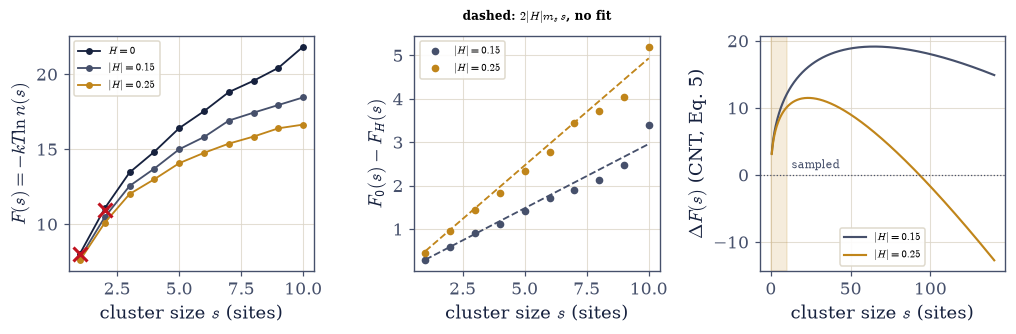

In [22]:
# (solution hidden on the public site)


## Exercise 6 — Which regime are we actually in? (student)

Every picture so far has assumed the textbook story: one critical droplet appears somewhere, and
grows until it has taken the lattice. That story is a *regime*, not a fact, and it is worth
finding out whether the parameters everyone uses are inside it.
Rikvold, Tomita, Miyashita and Sides {cite}`rikvold1994` divide the metastable lifetime of exactly
this model into four field regimes, and only one of them is the single-droplet picture. The
competition is between the waiting time $\tau$ for a droplet to appear anywhere and the time
$L/v$ for a droplet to sweep the lattice at its growth velocity. Because the nucleation rate is
proportional to the number of sites, doubling $L$ makes the wait four times shorter but the
crossing only twice as long, so *increasing the system size drives it out of the single-droplet
regime*, and it does so at a field that shrinks only as $1/\ln L$. There is no comfortable
lattice size.

Both regimes leave fingerprints that the lifetimes of Exercise 2 already contain, and neither
needs anything new to be built.

In the **single-droplet regime** the decay is one memoryless event whose probability per sweep is
proportional to the number of sites, so $\tau\propto L^{-2}$ and the product $\tau L^{2}$ is
independent of $L$, while the lifetime is exponentially distributed and its standard deviation
equals its mean. In the **multi-droplet regime** many droplets nucleate independently and the
lattice fills by their coalescence, so the decay time is an average over many events: it becomes
nearly deterministic, its relative width falls well below one, and it stops shrinking as
$L^{-2}$ because the growth of the droplets rather than the wait for one now sets the clock.
The two diagnostics are the constancy of $\tau L^{2}$ and the ratio of standard deviation to mean,
and a single sweep over lattice sizes at fixed field measures both.

We run at $|H|=0.30$, and include $L=40$ deliberately: that is the lattice of Exercise 11.4
of {cite}`sethna`, at the same temperature and very nearly the same field.

**Part a)** Using the `lifetime` of Exercise 2, collect 60 lifetimes at $T=1.5$, $|H|=0.30$ for
each of $L=12,16,24,32,40,48,64$ from seeds $900\ldots959$ with `max_sweeps=60000`, and report
$\tau$, $\tau L^{2}$ and the ratio of standard deviation to mean for each.

**Part b)** Identify the plateau of $\tau L^{2}$ over the three smallest lattices and report how
far the largest lattice has departed from it, and where $L=40$ falls.

**Part c)** Plot $\tau L^{2}$ and the relative width against $L$ on the same figure, marking the
single-droplet expectations (a horizontal line, and unity) and the position of the textbook
lattice.

In [23]:
# (solution hidden on the public site)


metastable lifetime across lattice size at T = 1.5, |H| = 0.3 (60 runs each):
     L      tau      tau*L^2    tau*L^2 / plateau    std/mean
    12     605.7       87223        0.97            1.21
    16     352.6       90274        1.00            1.01
    24     160.4       92390        1.03            0.82
    32     119.3      122197        1.36            0.71
    40      96.3      154133        1.71            0.61   <- Sethna's 40x40
    48      79.7      183590        2.04            0.44
    64      66.1      270609        3.01            0.25
  single-droplet plateau over L = 12, 16, 24: 89963 (flat to 3.0%), with std/mean near 1 — one memoryless event
  by L = 64 the product has risen 3.0x and the width has fallen to 0.25 — many droplets, averaging into a near-deterministic filling


### Validation 6

In [24]:
validate.check(
    plateau_spread < 0.10
    and rel_L[16] > 0.8
    and tauL2[64] > 2.0 * plateau
    and rel_L[64] < 0.5,
    "the single-droplet regime is identified by two independent fingerprints and "
    "both fail together at large L: tau*L^2 is flat and the lifetime width is 1 "
    "for L <= 24, while at L = 64 the product has more than doubled and the "
    "distribution has narrowed — the crossover Rikvold et al. describe",
    f"plateau flat to {100 * plateau_spread:.1f}%, std/mean {rel_L[16]:.2f} -> {rel_L[64]:.2f}, "
    f"tau*L^2 up {tauL2[64] / plateau:.1f}x",
)

✓  the single-droplet regime is identified by two independent fingerprints and both fail together at large L: tau*L^2 is flat and the lifetime width is 1 for L <= 24, while at L = 64 the product has more than doubled and the distribution has narrowed — the crossover Rikvold et al. describe   [plateau flat to 3.0%, std/mean 1.01 -> 0.25, tau*L^2 up 3.0x]


True

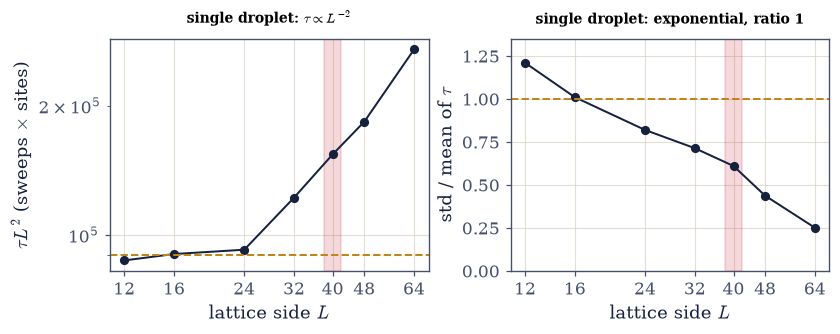

In [25]:
# (solution hidden on the public site)


## Exercise 7 — The lifetime against the field, and Onsager's coefficient (student)

The barrier of {eq}`eq-nuc-critical` scales as $1/|H|$, so the Arrhenius law
{eq}`eq-nuc-arrhenius` predicts something unusually specific: not that the lifetime grows as the
driving weakens, which is obvious, but that the *logarithm* of the lifetime is linear in the
*inverse* field, with a slope fixed entirely by Onsager's exact numbers,
$\Xi=\pi\sigma^{2}/(2m_skT)=1.503$ for the circular convention and $2\sigma^{2}/(m_skT)=1.914$
for the square one. Measuring $\ln\tau$ over a range of fields and reading off the slope is
therefore a test with no adjustable parameters in it at all.

The measurement runs at $L=24$, which Exercise 6 placed squarely on the single-droplet plateau at
$|H|=0.30$, and over the five fields $|H|=0.22,0.25,0.28,0.31,0.34$. That window is narrow, and
it is narrow for a reason worth stating: weaker fields make the lifetime grow exponentially past
what a notebook can afford, while stronger fields shrink the critical droplet towards a single
lattice spacing, where a sharp-interface theory has nothing left to describe. Roughly a factor of
thirty in the lifetime is what fits between those two walls.

A straight line through five points is easy to obtain and easy to over-read, so the fit is judged
against a rival rather than against itself. If the lifetime were governed by a power law
$\tau\propto|H|^{-n}$ instead of by a barrier, $\ln\tau$ would be linear in $\ln|H|$ rather than
in $1/|H|$; fitting both and comparing the coefficients of determination asks the data which
functional form it prefers, which is a question it can answer and a question it can answer the
other way.

One honest caveat travels with the slope. What {eq}`eq-nuc-arrhenius` calls a constant prefactor
is not constant: the Becker–Döring theory this notebook declines to develop gives it its own
power of $|H|$, which adds to the apparent slope over a narrow window. So a measured slope
somewhat above $\Xi$ is expected, and separating the two contributions would need a field range
we cannot reach.

**Part a)** Using the `lifetime` of Exercise 2, collect 48 lifetimes at $T=1.5$, $L=24$ for each
of $|H|=0.22,0.25,0.28,0.31,0.34$ from seeds $500\ldots547$ with `max_sweeps=40000`.

**Part b)** Fit $\ln\tau$ against $1/|H|$ with `numpy.polyfit` of degree 1, and separately fit
$\ln\tau$ against $\ln|H|$; report both coefficients of determination and both slopes.

**Part c)** Compare the fitted barrier coefficient with $\Xi$ from {eq}`eq-nuc-arrhenius` in both
the circular and the square convention, and plot $\ln\tau$ against $1/|H|$ with the fitted line
and the two theoretical slopes drawn through the data.

In [26]:
# (solution hidden on the public site)


metastable lifetime against field at T = 1.5, L = 24 (48 runs per field):
  |H| = 0.22   1/|H| =  4.55   tau =   2009.0   ln tau =  7.61
  |H| = 0.25   1/|H| =  4.00   tau =    645.3   ln tau =  6.47
  |H| = 0.28   1/|H| =  3.57   tau =    251.7   ln tau =  5.53
  |H| = 0.31   1/|H| =  3.23   tau =    119.4   ln tau =  4.78
  |H| = 0.34   1/|H| =  2.94   tau =     78.0   ln tau =  4.36
  Arrhenius fit  ln tau = 2.064/|H| + -1.800     R^2 = 0.9977
  power-law fit  ln tau = -7.59 ln|H| + const          R^2 = 0.9894
  the barrier coefficient Xi of eq-nuc-arrhenius, from Onsager alone:
    circular droplet  1.503   (measured / predicted = 1.37)
    square droplet    1.914   (measured / predicted = 1.08)
  lifetime spans a factor of 26 across the window


### Validation 7

In [27]:
validate.check(
    r2_arr > 0.99 and r2_arr > r2_pow and abs(slope_arr / XI_SQUARE - 1.0) < 0.25,
    "ln(lifetime) is linear in 1/|H| rather than in ln|H| — a barrier, not a power "
    "law — and its slope matches the square-droplet coefficient 2 sigma^2/(m_s kT) "
    "built from Onsager's exact tension and magnetization, with no fitted input",
    f"R^2 = {r2_arr:.4f} (power law {r2_pow:.4f}), slope {slope_arr:.3f} vs "
    f"Xi_square = {XI_SQUARE:.3f}, Xi_circle = {XI_CIRCLE:.3f}",
)

✓  ln(lifetime) is linear in 1/|H| rather than in ln|H| — a barrier, not a power law — and its slope matches the square-droplet coefficient 2 sigma^2/(m_s kT) built from Onsager's exact tension and magnetization, with no fitted input   [R^2 = 0.9977 (power law 0.9894), slope 2.064 vs Xi_square = 1.914, Xi_circle = 1.503]


True

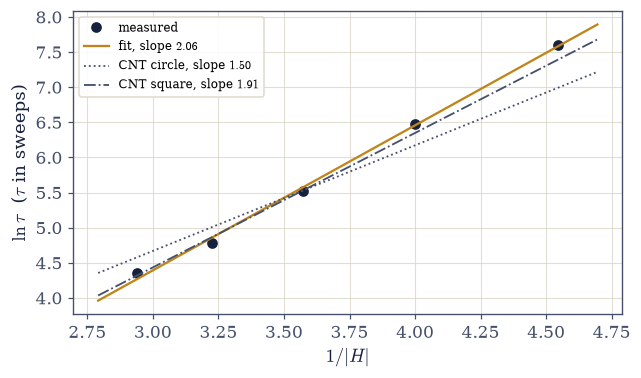

In [28]:
# (solution hidden on the public site)


## Exercise 8 — Nucleation is not coarsening (worked)

[§5.10](ising-emergence-universality.ipynb) already animated a lattice that starts disordered and
ends up magnetized, and it looks superficially like the animation of Exercise 3. The two processes
are different in kind, and confusing them is a standing hazard because both are done on the same
model with the same sampler. Sethna keeps them as separate exercises for exactly this reason {cite}`sethna`, and
so should we.

In a **temperature quench** the system is cooled from above $T_c$ to below it at zero field. The
state it arrives in, $m=0$, is not metastable but *unstable*: there is no barrier at all, ordered
domains begin growing from the first sweep, and what follows is **coarsening**, the slow
elimination of domain walls as small domains are swallowed by large ones. The driving force is
surface tension alone, the field plays no part, and because the $\mathbb{Z}_2$ symmetry of
{eq}`eq-nuc-hamiltonian` is untouched at $H=0$, which sign finally wins is decided by chance. The
characteristic domain size grows as a power of time, so the excess energy carried by the walls
falls as a power of time from the very first sweep.

In a **field reversal** at fixed temperature, which is this notebook's experiment, the state the
system finds itself in is metastable rather than unstable, the field breaks the symmetry outright,
and the outcome is never in doubt: the lattice will end up aligned with the field. What is in
doubt is *when*, and the waiting is the whole phenomenon.

Two measurements separate them cleanly, and both are checks that could come out the other way.
The first is the outcome: over 40 quenches the final sign should be a coin flip, while over 40
field reversals it should be the field's sign every single time. The second is the kinetics:
after a quench the excess bond energy $\varepsilon(t)-\varepsilon_{\rm eq}$ should decay as a
power law immediately, with no waiting time at all, while after a field reversal it should sit
flat until nucleation happens. We measure the coarsening exponent as well, without claiming more
than the data supports: the asymptotic Allen–Cahn value for a non-conserved order parameter is
$1/2$, and the effective exponent at the early times a notebook can afford is measurably steeper,
because the domains are still only a few interface widths across.

**Part a)** Run 40 temperature quenches from a random configuration to $T=1.5$ at $H=0$ on a
$32\times32$ lattice for 400 sweeps, and count how many end with $m>0$.

**Part b)** Run 40 field reversals at $T=1.5$, $|H|=0.25$ on the same lattice with the
`metastable_run` of Exercise 2, stopping each at $m<-0.5$ or 1500 sweeps, and count how many end
negative.

**Part c)** Measure the equilibrium bond energy per site of the ordered phase at $T=1.5$, then
average the excess bond energy over 12 quenches of a $96\times96$ lattice for 250 sweeps and fit
$\ln(\varepsilon-\varepsilon_{\rm eq})$ against $\ln t$ over $t\in[10,200]$ with
`numpy.polyfit`, reporting the exponent and its coefficient of determination.

In [29]:
# (solution hidden on the public site)


coarsening (quench in temperature) against nucleation (reversal of the field):
  quench, H = 0:      20/40 runs end with m > 0 — the Z2 symmetry is intact and the sign is a coin flip
  field reversal:     40/40 runs end aligned with the field — the outcome was never in doubt, only its timing
  equilibrium bond energy per site at T = 1.5: -1.9502
  excess bond energy after a quench decays as t^(-0.71) over t in [10, 200], R^2 = 0.9863
  (the asymptotic Allen-Cahn exponent is -1/2; at these early times the measured decay is steeper, since the domains are still only a few walls wide)


### Validation 8

In [30]:
validate.check(
    12 <= positive_endings <= 28
    and negative_endings == 40
    and -0.85 < coars_slope < -0.35
    and coars_r2 > 0.97,
    "a temperature quench and a field reversal are different processes: the "
    "quench keeps the Z2 symmetry and picks its sign at random while every "
    "reversal ends aligned with the field, and the quench's wall energy decays "
    "as a power law from the first sweep instead of waiting behind a barrier",
    f"quench {positive_endings}/40 positive, reversal {negative_endings}/40 negative, "
    f"coarsening exponent {coars_slope:.2f} (R^2 = {coars_r2:.3f})",
)

✓  a temperature quench and a field reversal are different processes: the quench keeps the Z2 symmetry and picks its sign at random while every reversal ends aligned with the field, and the quench's wall energy decays as a power law from the first sweep instead of waiting behind a barrier   [quench 20/40 positive, reversal 40/40 negative, coarsening exponent -0.71 (R^2 = 0.986)]


True

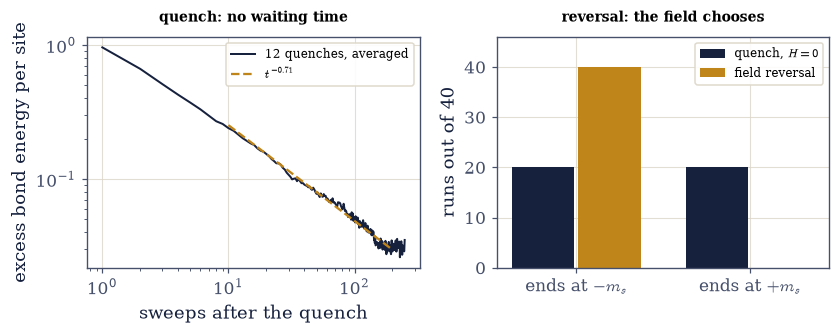

In [31]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
Ask your assistant for a different reaction coordinate for the critical droplet — the largest
cluster in the whole lattice rather than the one containing the centre, or the total minority
area, or the perimeter instead of the area — and rebuild the committor of Exercise 4 on it. The
gate is the scaling law, not the number: whatever coordinate it proposes, the half-way crossing
must still fall as $1/|H|$ across $|H|=0.15$, $0.20$ and $0.25$ to the same 15% this notebook
measured, and any coordinate for which it does not is telling you it is not tracking the droplet.
The check is yours.
```

## Notebook summary

We gave the Ising model of [§5.10](ising-emergence-universality.ipynb) an external field, which
cost two lines of code and bought a genuinely new phenomenon: a phase that is wrong and stable at
the same time.

- **The field in the energy** {eq}`eq-nuc-hamiltonian`, {eq}`eq-nuc-dE`: $\Delta
  E_i=2\sigma_i(\sum_j\sigma_j+H)$, with the field inside the bracket. Certified against a
  brute-force energy difference at every site (agreement to $9\times10^{-16}$), against the
  zero-field sweep of [§5.10](ising-emergence-universality.ipynb) bitwise at $H=0$ on a
  configuration in which half the sites move, and against itself at $H=0.4$, where the two sweeps
  part company at 86% of sites.
- **Metastability is a waiting time, not a drift.** After reversing the field at $T=1.5$,
  $|H|=0.25$, the magnetization holds at $+m_s=0.9865$ and then collapses. Over 150 seeded runs at
  $L=24$ the lifetime came out exponentially distributed, with standard deviation $0.88$ of the
  mean and a survival curve straight on a logarithmic axis to $R^{2}=0.99$: the decay is one
  memoryless rare event.
- **The critical droplet, measured twice.** Seeding squares and asking which survive gave
  $\ell_{50}=9.7$, $7.6$ and $6.4$ at $|H|=0.15$, $0.20$, $0.25$, so $\ell_{50}|H|$ is constant to
  $11\%$ — the $1/|H|$ scaling {eq}`eq-nuc-square` demands — sitting $20$ to $33\%$ above the
  sharp-interface prediction, since a seeded square carries perimeter the equilibrium shape does
  not.
- **The free energy, read off a histogram** {eq}`eq-nuc-clusterfe`. Cluster statistics reproduced
  the exact costs $F(1)=8J$ (measured $8.03$) and $F(2)=12J-kT\ln2$ (measured $11.06$ against
  $10.96$), and the difference between the $H=0$ and $H\neq0$ histograms isolated the bulk term
  with slope $0.303$ and $0.491$ against Onsager's $2|H|m_s=0.296$ and $0.493$. The surface
  coefficient of ten-site clusters came out $6.16$, between the asymptotic $4\sigma=4.76$ and the
  entropy-free $8J$, which is why extrapolating this route to the barrier overshoots by two
  thirds.
- **The Arrhenius law** {eq}`eq-nuc-arrhenius`: $\ln\tau=2.064/|H|-1.80$ across a factor of $26$
  in lifetime, with $R^{2}=0.998$ against $0.989$ for the power-law rival, and the slope within
  $8\%$ of the square-droplet coefficient $2\sigma^{2}/(m_skT)=1.914$ assembled from Onsager's
  exact tension and magnetization with nothing fitted.
- **The regime, checked rather than assumed.** $\tau L^{2}$ is flat to $3\%$ and the lifetime
  width is $1$ for $L\le24$, and by $L=64$ the product has tripled and the width has fallen to
  $0.25$. The $40\times40$ lattice of the standard textbook exercise, at the same temperature and
  very nearly the same field, sits at $1.7$ times the plateau with a width of $0.61$: past the
  crossover Rikvold and co-workers describe {cite}`rikvold1994`, and therefore not running the
  one-droplet story it is used to illustrate.
- **Coarsening is a different process.** A temperature quench ends at $+m_s$ in $20$ of $40$ runs
  and loses wall energy as a power law from the first sweep; a field reversal ends aligned with
  the field in $40$ of $40$ and does nothing at all until it nucleates.

What we did not compute, and said so at every opportunity: the rate prefactor, which is
Becker–Döring kinetics and a Fokker–Planck equation in cluster-size space, and which is also the
reason the fitted slope $2.064$ sits a little above the barrier coefficient it is compared with.

## Outlook

- **The prefactor, and the kinetics behind it.** Everything here lives in the exponent. The rate
  in front of it needs the probability current through the saddle in cluster-size space: the
  Becker–Döring master equation, its continuum Fokker–Planck limit, and Zeldovich's factor for the
  fraction of critical droplets that recross rather than commit. Landau and Lifshitz, *Physical
  Kinetics* §99 {cite}`ll_kinetics` develops it in full, importing the barrier from equilibrium statistical mechanics
  exactly as we did. Kramers' escape problem is the same mathematics in one dimension.
- **Reaching the barrier top honestly.** Exercise 5 stopped where the counts ran out, which is
  two decades of probability short of the saddle. Umbrella sampling biases the simulation towards
  the cluster sizes it never visits and removes the bias afterwards; forward-flux and transition
  interface sampling do the dynamical version, and give the rate rather than only the free energy.
  These belong to the molecular-simulation courses [§5.11](taste-of-nonequilibrium.ipynb) points
  to, and to the Materials Modelling course.
- **Heterogeneous nucleation, which is what actually happens.** Real systems almost never nucleate
  in the bulk: a wall, a dust grain, or a scratch on a mug offers a surface that removes part of
  the droplet's perimeter and therefore part of the barrier. A single fixed down spin held in this
  lattice would show it immediately, and it is why a boiling chip works and why superheated water
  in a smooth mug does not.
- **The same barrier, everywhere else.** The competition between a perimeter and an area is not
  about magnets. It is the condensation of a droplet in a cloud chamber, the birth of a bubble in
  a superheated liquid, the precipitation of a second phase in an alloy, the folding nucleus of a
  protein, and the metastable strip of [§5.15](van-der-waals.ipynb) between binodal and spinodal
  that sent us here. Change what $\sigma$ and $\Delta f$ mean and the arithmetic is untouched.
- **Cross-reference** [§5.10](ising-emergence-universality.ipynb) (the model, the sampler, and the
  sibling temperature quench), [§5.8](partition-function.ipynb) (Metropolis),
  [§5.15](van-der-waals.ipynb) (the metastable strip),
  [§5.17](molecular-dynamics.ipynb) (blocked error bars on correlated Monte Carlo output), and
  [E.3](../epilogue/universality.ipynb) (measuring a scaling claim rather than asserting it).

### References

```{bibliography}
:filter: docname in docnames
```

In [32]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>